In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!unzip "/content/drive/MyDrive/malof_lab/aem_dataset.zip" -d '/content/temp/'
!unzip "/content/temp/ADM.zip" -d "/content/adm/"

Mounted at /content/drive
Archive:  /content/drive/MyDrive/malof_lab/aem_dataset.zip
 extracting: /content/temp/README.txt  
 extracting: /content/temp/Nano.zip  
 extracting: /content/temp/ADM.zip   
Archive:  /content/temp/ADM.zip
   creating: /content/adm/ADM/
  inflating: /content/adm/ADM/data_g.csv  
  inflating: /content/adm/ADM/data_s.csv  
   creating: /content/adm/ADM/testset/
  inflating: /content/adm/ADM/testset/test_g.csv  
  inflating: /content/adm/ADM/testset/test_s.csv  


In [ ]:
# ========================= CELL 1: FOUNDATION (define everything) =========================
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device, "| torch:", torch.__version__)

# ---- data paths (your setup) ----
TRAIN_X = "/content/adm/ADM/data_g.csv"
TRAIN_Y = "/content/adm/ADM/data_s.csv"
TEST_X  = "/content/adm/ADM/testset/test_g.csv"
TEST_Y  = "/content/adm/ADM/testset/test_s.csv"

# ---- checkpoint paths (Drive = persists). Point at existing files to skip retraining. ----
CKPT_DIR = "/content/drive/MyDrive/malof_lab/"
os.makedirs(CKPT_DIR, exist_ok=True)
MLP_CKPT   = CKPT_DIR + "mlp_baseline.pt"
TF_CKPT    = CKPT_DIR + "transformer_correct.pt"
SI_K3_CKPT = CKPT_DIR + "grid_k3.pt"
SI_K5_CKPT = CKPT_DIR + "grid_k5.pt"

# ---- normalization ----
def normalize(x, x_max=None, x_min=None):
    if x_max is None:
        x_max, x_min = x.max(axis=0), x.min(axis=0)
    x_range = (x_max - x_min) / 2.0
    x_range = np.where(x_range == 0, 1e-8, x_range)
    x_avg   = (x_max + x_min) / 2.0
    return (x - x_avg) / x_range, x_max, x_min

def build_grid(g, x_max=None, x_min=None):
    """raw (n,14) -> normalized grid (n,2,2,5) with channels [rx, ry, theta, h, p]."""
    g, x_max, x_min = normalize(g, x_max, x_min)
    n = g.shape[0]
    grid = np.zeros((n, 2, 2, 5), dtype='float32')
    for i in range(4):
        r, c = i // 2, i % 2
        grid[:, r, c, 0] = g[:, 2 + 2*i]   # rx
        grid[:, r, c, 1] = g[:, 3 + 2*i]   # ry
        grid[:, r, c, 2] = g[:, 10 + i]    # theta
        grid[:, r, c, 3] = g[:, 0]         # h
        grid[:, r, c, 4] = g[:, 1]         # p
    return grid, x_max, x_min

# ---- datasets / loaders ----
class TensorData(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):  return len(self.x)
    def __getitem__(self, i): return self.x[i], self.y[i]

def load_flat(batch_size):
    tx = pd.read_csv(TRAIN_X, header=None).astype('float32').values
    ty = pd.read_csv(TRAIN_Y, header=None).astype('float32').values
    ex = pd.read_csv(TEST_X,  header=None).astype('float32').values
    ey = pd.read_csv(TEST_Y,  header=None).astype('float32').values
    tx, xm, xn = normalize(tx); ex, _, _ = normalize(ex, xm, xn)
    xtr, xv, ytr, yv = train_test_split(tx, ty, test_size=0.2, random_state=0)
    tl = DataLoader(TensorData(xtr, ytr), batch_size=batch_size, shuffle=True)
    vl = DataLoader(TensorData(xv,  yv),  batch_size=batch_size, shuffle=False)
    return tl, vl, ex, ey

def load_grid(batch_size):
    tx = pd.read_csv(TRAIN_X, header=None).astype('float32').values
    ty = pd.read_csv(TRAIN_Y, header=None).astype('float32').values
    ex = pd.read_csv(TEST_X,  header=None).astype('float32').values
    ey = pd.read_csv(TEST_Y,  header=None).astype('float32').values
    gtr, xm, xn = build_grid(tx); gex, _, _ = build_grid(ex, xm, xn)
    xtr, xv, ytr, yv = train_test_split(gtr, ty, test_size=0.2, random_state=0)
    tl = DataLoader(TensorData(xtr, ytr), batch_size=batch_size, shuffle=True)
    vl = DataLoader(TensorData(xv,  yv),  batch_size=batch_size, shuffle=False)
    return tl, vl, gex, ey

# ---- models ----
class MLP(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.linears    = nn.ModuleList(nn.Linear(layers[i], layers[i+1]) for i in range(len(layers)-1))
        self.bn_linears = nn.ModuleList(nn.BatchNorm1d(layers[i+1])       for i in range(len(layers)-1))
    def forward(self, g):
        out = g
        for i, (fc, bn) in enumerate(zip(self.linears, self.bn_linears)):
            out = F.relu(bn(fc(out))) if i < len(self.linears)-1 else fc(out)
        return out

class ScaleInvariantMetasurface(nn.Module):
    def __init__(self, N=2, K=3, C=5, n_freq=2001, hidden=2000, n_hidden=10):
        super().__init__()
        self.N, self.K, self.C, self.pad, self.n_freq = N, K, C, K//2, n_freq
        self.f_theta = MLP([K*K*C] + [hidden]*n_hidden + [n_freq])
    def forward(self, grid):
        B, N, K, C, pad = grid.shape[0], self.N, self.K, self.C, self.pad
        src = (torch.arange(N + 2*pad, device=grid.device) - pad) % N      # periodic padding
        padded = grid[:, src[:, None], src[None, :], :]
        x = torch.zeros(B, N*N, K*K*C, device=grid.device)
        for idx in range(N*N):
            i, j = idx // N, idx % N
            x[:, idx, :] = padded[:, i:i+K, j:j+K, :].reshape(B, K*K*C)
        z = self.f_theta(x.reshape(B*N*N, K*K*C)).reshape(B, N*N, self.n_freq)
        return z.mean(dim=1)                                               # average over neighborhoods

class TransformerModel(nn.Module):
    def __init__(self, head_linear, seq_len, d_model, nhead, dim_ff, num_layers, dim_s, batch_first=True):
        super().__init__()
        self.seq_len = seq_len
        self.head_linears    = nn.ModuleList(nn.Linear(head_linear[i], head_linear[i+1]) for i in range(len(head_linear)-1))
        self.head_bn_linears = nn.ModuleList(nn.BatchNorm1d(head_linear[i+1])            for i in range(len(head_linear)-1))
        enc = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_ff, batch_first=batch_first)
        self.transformer_encoder = nn.TransformerEncoder(enc, num_layers=num_layers)
        self.tail = nn.Linear(seq_len * d_model, dim_s)
    def forward(self, g):
        out = g
        for i, (fc, bn) in enumerate(zip(self.head_linears, self.head_bn_linears)):
            out = F.relu(bn(fc(out))) if i < len(self.head_linears)-1 else fc(out)
        out = out.view(out.size(0), self.seq_len, -1)
        out = self.transformer_encoder(out)
        return self.tail(out.reshape(out.size(0), -1))

# ---- train / eval helpers ----
def evaluate(model, loader):
    crit = nn.MSELoss(); model.eval(); tot = 0.0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            tot += crit(model(xb), yb).item()
    return tot / len(loader)

def run_training(model, train_loader, val_loader, optimizer, scheduler, sched_mode,
                 epochs, ckpt_path, eval_step=10, clip=None):
    crit = nn.MSELoss(); best = float('inf'); t0 = time.time()
    for epoch in range(epochs):
        model.train(); tr = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = crit(model(xb), yb); loss.backward()
            if clip is not None: torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            optimizer.step(); tr += loss.item()
        tr /= len(train_loader)
        if epoch % eval_step == 0:
            va = evaluate(model, val_loader)
            print(f"  epoch {epoch:3d} | train {tr:.6f} | val {va:.6f} | lr {optimizer.param_groups[0]['lr']:.1e}")
            if va < best: best = va; torch.save(model.state_dict(), ckpt_path)
        if   sched_mode == 'plateau_train': scheduler.step(tr)
        elif sched_mode == 'cosine':        scheduler.step()
    print(f"  done in {(time.time()-t0)/60:.1f} min | best val {best:.6f}")
    return best

# ---- architecture configs ----
LAYERS      = [14] + [2000]*10 + [2001]            # MLP / baseline
HEAD_LINEAR = [14] + [500]*8 + [6144]              # transformer head (-> 12 x 512)
SEQ_LEN, D_MODEL, NHEAD, NUM_LAYERS = 12, 512, 8, 6

# build the test arrays once (same test rows & order for every model)
_, _, test_x_flat, test_y = load_flat(1024)
_, _, test_grid,   _      = load_grid(1024)
print("test_x_flat:", test_x_flat.shape, "| test_grid:", test_grid.shape, "| test_y:", test_y.shape)


device: cuda | torch: 2.11.0+cu128
test_x_flat: (5868, 14) | test_grid: (5868, 2, 2, 5) | test_y: (5868, 2001)


In [ ]:
# ========================= CELL 2: TRAIN any model whose checkpoint is missing =========================
# (delete a .pt file on Drive to force a retrain; point CKPT vars at existing files to skip)

# --- MLP (flat, batch 1024) ---
if not os.path.exists(MLP_CKPT):
    print("Training MLP...")
    tl, vl, _, _ = load_flat(1024)
    m = MLP(LAYERS).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=1e-4, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.2, patience=10)
    run_training(m, tl, vl, opt, sch, 'plateau_train', epochs=500, ckpt_path=MLP_CKPT)
else: print("MLP checkpoint found, skipping.")

# --- Grid K=3 (grid, batch 1024) ---
if not os.path.exists(SI_K3_CKPT):
    print("Training Grid K=3...")
    tl, vl, _, _ = load_grid(1024)
    m = ScaleInvariantMetasurface(N=2, K=3, C=5, n_freq=2001).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=1e-4, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.2, patience=10)
    run_training(m, tl, vl, opt, sch, 'plateau_train', epochs=500, ckpt_path=SI_K3_CKPT)
else: print("Grid K=3 checkpoint found, skipping.")

# --- Grid K=5 (grid, batch 1024) ---
if not os.path.exists(SI_K5_CKPT):
    print("Training Grid K=5...")
    tl, vl, _, _ = load_grid(1024)
    m = ScaleInvariantMetasurface(N=2, K=5, C=5, n_freq=2001).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=1e-4, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.2, patience=10)
    run_training(m, tl, vl, opt, sch, 'plateau_train', epochs=500, ckpt_path=SI_K5_CKPT)
else: print("Grid K=5 checkpoint found, skipping.")

# --- Transformer (correct: batch_first=True, dim_ff=2048, AdamW + cosine + clip; flat, batch 256) ---
if not os.path.exists(TF_CKPT):
    print("Training Transformer (correct)...")
    tl, vl, _, _ = load_flat(256)
    m = TransformerModel(HEAD_LINEAR, SEQ_LEN, D_MODEL, NHEAD, dim_ff=2048,
                         num_layers=NUM_LAYERS, dim_s=2001, batch_first=True).to(device)
    opt = torch.optim.AdamW(m.parameters(), lr=1e-4, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=300, eta_min=1e-6)
    run_training(m, tl, vl, opt, sch, 'cosine', epochs=300, ckpt_path=TF_CKPT, clip=1.0)
else: print("Transformer checkpoint found, skipping.")


MLP checkpoint found, skipping.
Grid K=3 checkpoint found, skipping.
Grid K=5 checkpoint found, skipping.
Transformer checkpoint found, skipping.



model              mean MSE   median MSE
MLP               1.558e-03    1.429e-03
Transformer       2.332e-03    2.108e-03
Grid K=3          2.830e-03    2.528e-03
Grid K=5          3.670e-03    3.356e-03

Paper: MLP 1.23e-3 | Transformer 1.47e-3

best / worst sample per model:
  MLP          best idx 4968 (2.37e-04) | worst idx 4713 (4.98e-03)
  Transformer  best idx 2615 (2.49e-04) | worst idx 4713 (9.94e-03)
  Grid K=3     best idx  550 (3.32e-04) | worst idx 3452 (2.16e-02)
  Grid K=5     best idx 2738 (5.70e-04) | worst idx 3452 (1.86e-02)


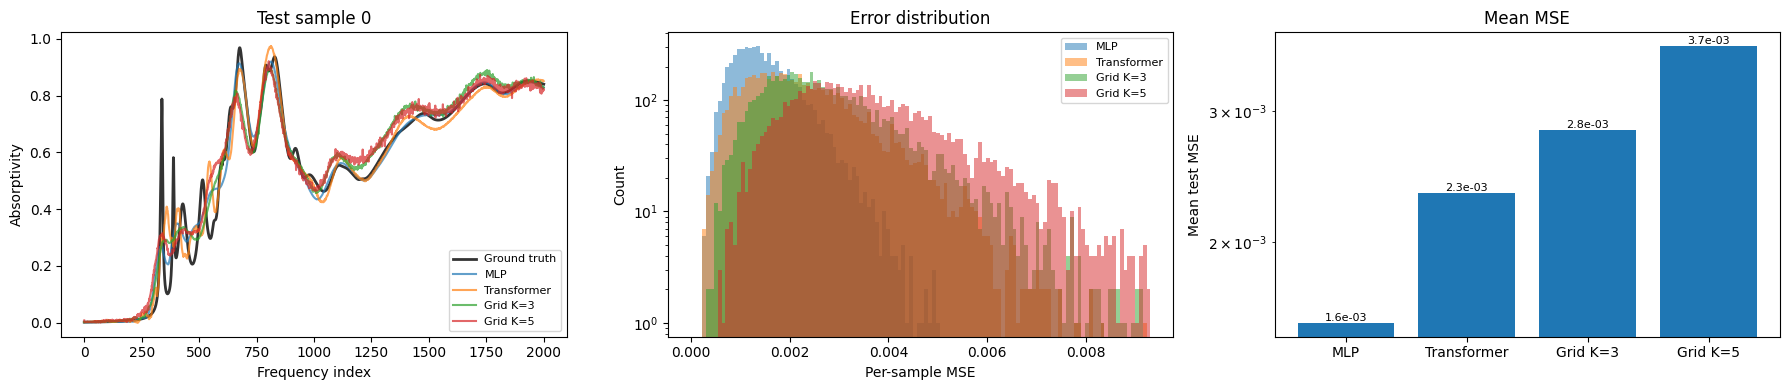

In [ ]:
# ========================= CELL 3: COMPARE all four + plots =========================
models_to_eval = {
    'MLP':         (MLP(LAYERS),                                    MLP_CKPT,   test_x_flat),
    'Transformer': (TransformerModel(HEAD_LINEAR, SEQ_LEN, D_MODEL, NHEAD, dim_ff=2048,
                                     num_layers=NUM_LAYERS, dim_s=2001, batch_first=True),
                                                                    TF_CKPT,    test_x_flat),
    'Grid K=3':    (ScaleInvariantMetasurface(N=2, K=3, C=5, n_freq=2001), SI_K3_CKPT, test_grid),
    'Grid K=5':    (ScaleInvariantMetasurface(N=2, K=5, C=5, n_freq=2001), SI_K5_CKPT, test_grid),
}

preds, mean_mse, med_mse = {}, {}, {}
for name, (m, ckpt, xin) in models_to_eval.items():
    if not os.path.exists(ckpt):
        print(f"skip {name}: no checkpoint at {ckpt}"); continue
    m = m.to(device); m.load_state_dict(torch.load(ckpt, map_location=device)); m.eval()
    out = []
    with torch.no_grad():
        xt = torch.tensor(xin, dtype=torch.float32)
        for i in range(0, len(xt), 512):
            out.append(m(xt[i:i+512].to(device)).cpu().numpy())
    p = np.concatenate(out, 0); preds[name] = p
    per = ((p - test_y) ** 2).mean(axis=1)
    mean_mse[name], med_mse[name] = per.mean(), np.median(per)

# ---- table ----
print(f"\n{'model':<14}{'mean MSE':>13}{'median MSE':>13}")
for n in preds: print(f"{n:<14}{mean_mse[n]:>13.3e}{med_mse[n]:>13.3e}")
print(f"\nPaper: MLP 1.23e-3 | Transformer 1.47e-3")

# ---- best/worst per model ----
print("\nbest / worst sample per model:")
for n in preds:
    per = ((preds[n]-test_y)**2).mean(axis=1)
    print(f"  {n:<12} best idx {per.argmin():4d} ({per.min():.2e}) | worst idx {per.argmax():4d} ({per.max():.2e})")

# ---- plots ----
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
idx = 0
ax[0].plot(test_y[idx], 'k', lw=2, alpha=0.8, label='Ground truth')
for n in preds: ax[0].plot(preds[n][idx], alpha=0.7, label=n)
ax[0].set_title(f'Test sample {idx}'); ax[0].set_xlabel('Frequency index')
ax[0].set_ylabel('Absorptivity'); ax[0].legend(fontsize=8)

allper = {n: ((preds[n]-test_y)**2).mean(axis=1) for n in preds}
cap = max(np.percentile(p, 99) for p in allper.values())
for n, per in allper.items(): ax[1].hist(per, bins=120, range=(0, cap), alpha=0.5, label=n)
ax[1].set_yscale('log'); ax[1].set_xlabel('Per-sample MSE'); ax[1].set_ylabel('Count')
ax[1].set_title('Error distribution'); ax[1].legend(fontsize=8)

names = list(preds.keys())
ax[2].bar(names, [mean_mse[n] for n in names])
ax[2].set_yscale('log'); ax[2].set_ylabel('Mean test MSE'); ax[2].set_title('Mean MSE')
for i, n in enumerate(names):
    ax[2].text(i, mean_mse[n], f'{mean_mse[n]:.1e}', ha='center', va='bottom', fontsize=8)
plt.tight_layout(); plt.show()
